# Intensity Transformations and Neighborhood Filtering

## Q 01

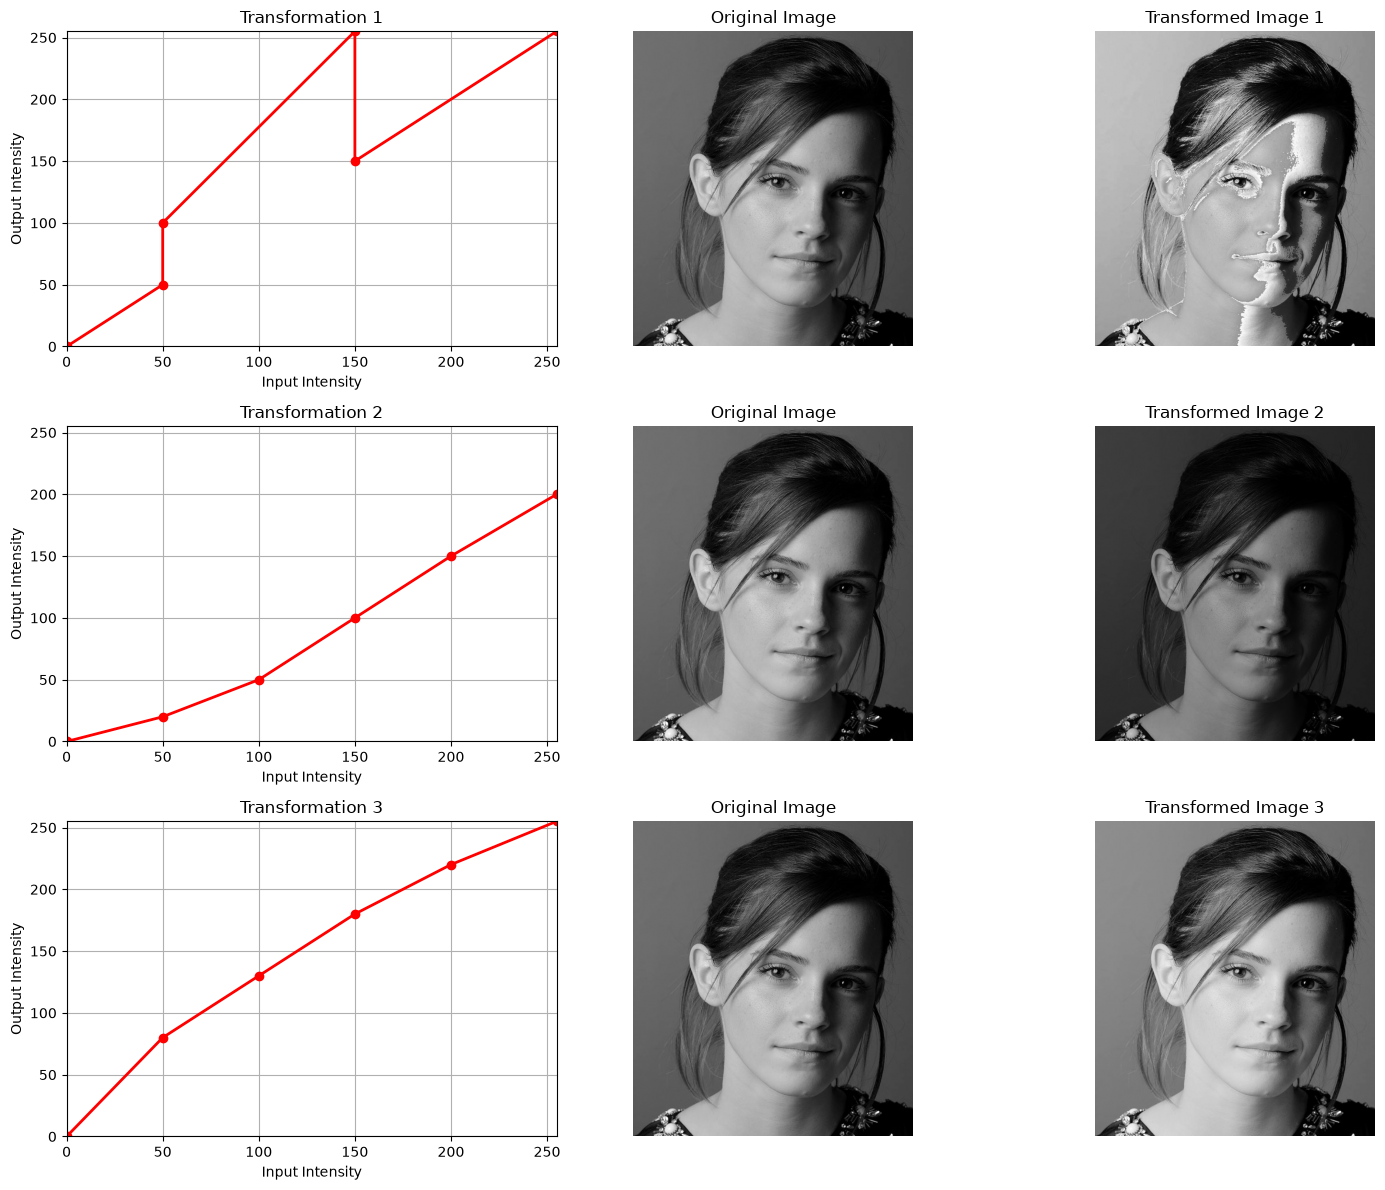

In [14]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


def intensity_transform(im: np.ndarray, breakpoints: list) -> np.ndarray:
    bp = np.array(breakpoints, dtype=np.float32)
    x_in = np.arange(256)
    lut = np.interp(x_in, bp[:, 0], bp[:, 1]).astype(np.uint8)
    return cv.LUT(im, lut)


# Load image
img = cv.imread('images/q1.jpeg', cv.IMREAD_GRAYSCALE)


# Three different breakpoint sets
breakpoints_list = [
    [
        [0, 0],
        [50, 50],
        [50, 100],
        [150, 255],
        [150, 150],
        [255, 255]
    ],

    [
        [0, 0],
        [50, 20],
        [100, 50],
        [150, 100],
        [200, 150],
        [255, 200]
    ],

    [
        [0, 0],
        [50, 80],
        [100, 130],
        [150, 180],
        [200, 220],
        [255, 255]
    ]
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))


for row, breakpoints in enumerate(breakpoints_list):
    transformed_img = intensity_transform(img, breakpoints)

    bp = np.array(breakpoints)

    # Column 1: Transformation curve
    axes[row, 0].plot(bp[:, 0],bp[:, 1],'r-o',linewidth=2)
    axes[row, 0].set_title(f'Transformation {row + 1}')

    axes[row, 0].set_xlabel('Input Intensity')
    axes[row, 0].set_ylabel('Output Intensity')
    axes[row, 0].set_xlim([0, 255])
    axes[row, 0].set_ylim([0, 255])
    axes[row, 0].grid(True)

    # Column 2: Original image
    axes[row, 1].imshow(img,cmap='gray',vmin=0,vmax=255)
    axes[row, 1].set_title('Original Image')
    axes[row, 1].axis('off')

    # Column 3: Transformed image
    axes[row, 2].imshow(transformed_img,cmap='gray',vmin=0,vmax=255)
    axes[row, 2].set_title(f'Transformed Image {row + 1}')
    axes[row, 2].axis('off')


plt.tight_layout()
plt.show()

## Q 02

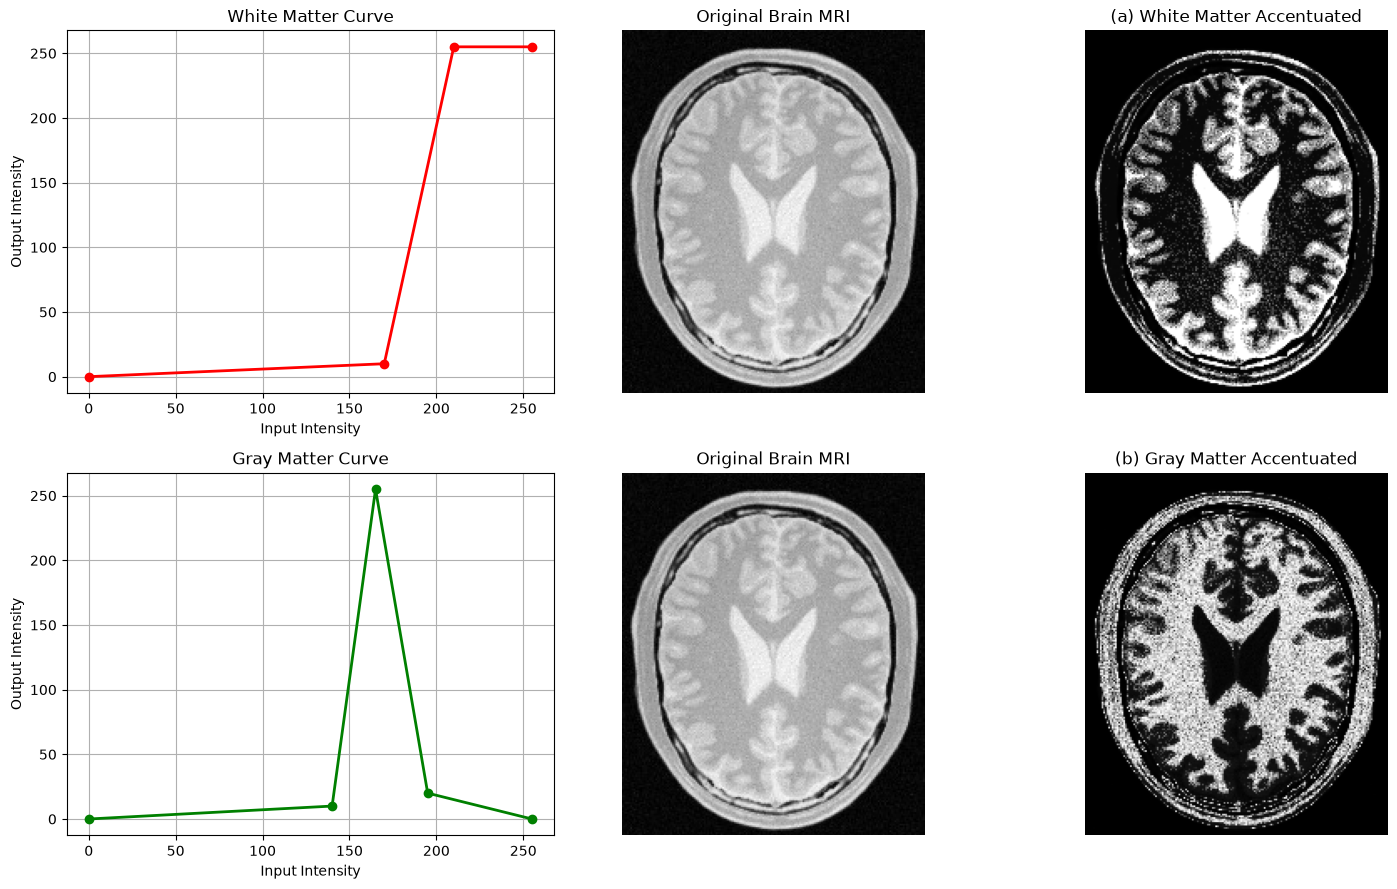

In [25]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im: np.ndarray, breakpoints: list) -> np.ndarray:
    """Applies piecewise linear intensity transformation using lookup table."""
    bp = np.array(breakpoints, dtype=np.float32)
    x = np.arange(256)
    lut = np.interp(x, bp[:, 0], bp[:, 1]).astype(np.uint8)
    return cv.LUT(im, lut)

img = cv.imread('images/q2.jpeg', cv.IMREAD_GRAYSCALE)
bp_white_matter = [
    [0, 0],
    [170, 10],
    [210, 255],
    [255, 255]
]

bp_gray_matter = [
    [0, 0],
    [140, 10],
    [165, 255],
    [195, 20],
    [255, 0]
]

img_wm = intensity_transform(img, bp_white_matter)
img_gm = intensity_transform(img, bp_gray_matter)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
#plot white matter transformation curve and images
bp_wm = np.array(bp_white_matter)

axes[0, 0].plot(bp_wm[:, 0], bp_wm[:, 1], 'r-o', linewidth=2)
axes[0, 0].set_title('White Matter Curve')
axes[0, 0].set_xlabel('Input Intensity')
axes[0, 0].set_ylabel('Output Intensity')
axes[0, 0].grid(True)

axes[0, 1].imshow(img, cmap='gray')
axes[0, 1].set_title('Original Brain MRI')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_wm, cmap='gray')
axes[0, 2].set_title('(a) White Matter Accentuated')
axes[0, 2].axis('off')

#plot gray matter transformation curve and images
bp_gm = np.array(bp_gray_matter)
axes[1, 0].plot(bp_gm[:, 0], bp_gm[:, 1], 'g-o', linewidth=2)
axes[1, 0].set_title('Gray Matter Curve')
axes[1, 0].set_xlabel('Input Intensity')
axes[1, 0].set_ylabel('Output Intensity')
axes[1, 0].grid(True)

axes[1, 1].imshow(img, cmap='gray')
axes[1, 1].set_title('Original Brain MRI')
axes[1, 1].axis('off')

axes[1, 2].imshow(img_gm, cmap='gray')
axes[1, 2].set_title('(b) Gray Matter Accentuated')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

### Histogram plots


C:\Users\User\AppData\Local\Temp\ipykernel_14244\1097912072.py:4: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[0].hist(img.ravel(), 256, [0, 256], color='gray', alpha=0.8)
C:\Users\User\AppData\Local\Temp\ipykernel_14244\1097912072.py:12: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1].hist(img_wm.ravel(), 256, [0, 256], color='crimson', alpha=0.8)
C:\Users\User\AppData\Local\Temp\ipykernel_14244\1097912072.py:20: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[2].hist(img_gm.ravel(), 256, [0, 256], color='forestgreen', alpha=0.8)


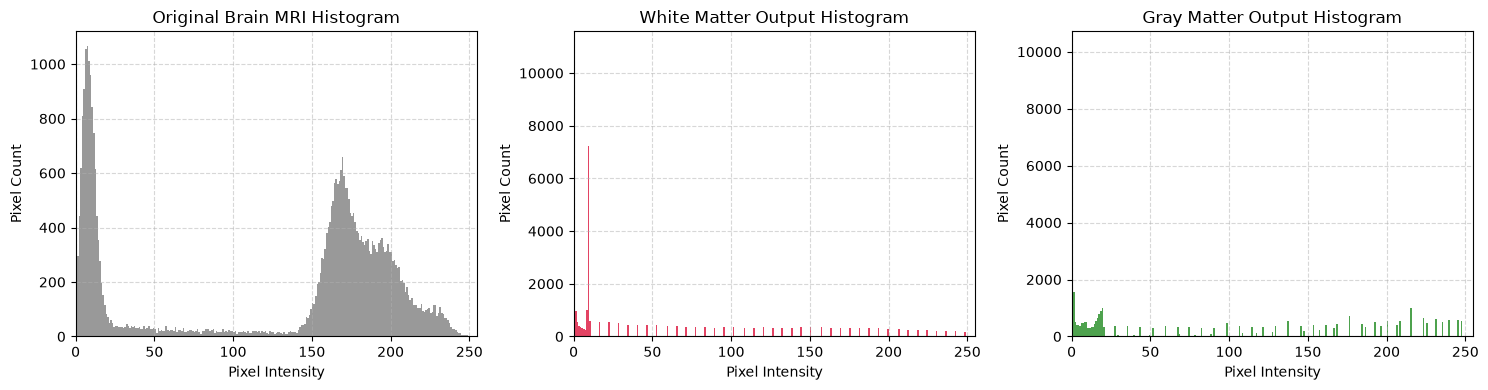

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Original Brain MRI Histogram
axes[0].hist(img.ravel(), 256, [0, 256], color='gray', alpha=0.8)
axes[0].set_title('Original Brain MRI Histogram')
axes[0].set_xlabel('Pixel Intensity')
axes[0].set_ylabel('Pixel Count')
axes[0].set_xlim([0, 255])
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. White Matter Accentuated Histogram
axes[1].hist(img_wm.ravel(), 256, [0, 256], color='crimson', alpha=0.8)
axes[1].set_title('White Matter Output Histogram')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Pixel Count')
axes[1].set_xlim([0, 255])
axes[1].grid(True, linestyle='--', alpha=0.5)

# 3. Gray Matter Accentuated Histogram
axes[2].hist(img_gm.ravel(), 256, [0, 256], color='forestgreen', alpha=0.8)
axes[2].set_title('Gray Matter Output Histogram')
axes[2].set_xlabel('Pixel Intensity')
axes[2].set_ylabel('Pixel Count')
axes[2].set_xlim([0, 255])
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Q 03


C:\Users\User\AppData\Local\Temp\ipykernel_13304\3228552308.py:29: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1, 0].hist(l_plane.ravel(), 256, [0, 256], color='black', alpha=0.75)
C:\Users\User\AppData\Local\Temp\ipykernel_13304\3228552308.py:35: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1, 1].hist(l_corrected.ravel(), 256, [0, 256], color='royalblue', alpha=0.75)


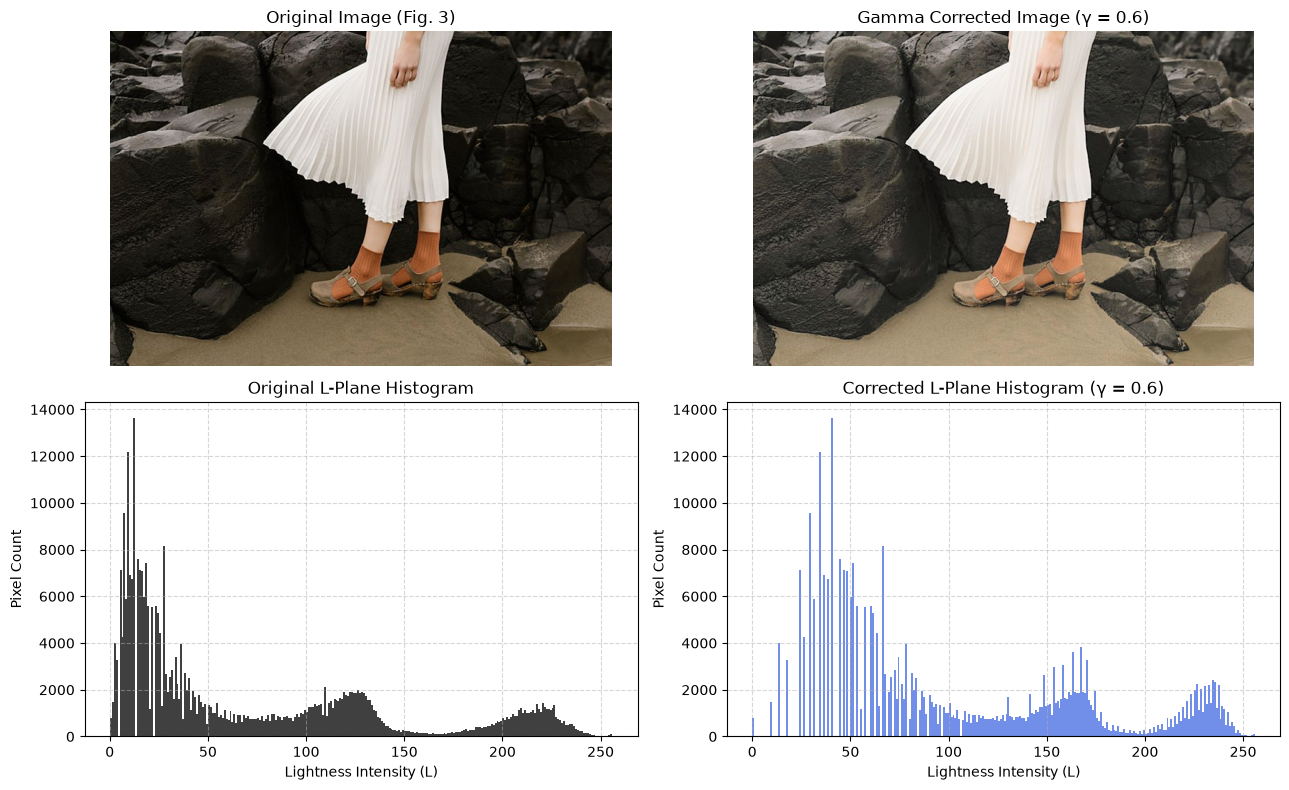

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


img_bgr = cv.imread('images/q3.jpeg')
img_lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2LAB) #image converted to LAB color space
l_plane, a_plane, b_plane = cv.split(img_lab)

gamma = 0.6 
l_norm = l_plane / 255.0
l_corrected = np.clip(np.power(l_norm, gamma) * 255.0, 0, 255).astype(np.uint8)

img_lab_corrected = cv.merge([l_corrected, a_plane, b_plane])
img_rgb_corrected = cv.cvtColor(img_lab_corrected, cv.COLOR_LAB2RGB)
img_rgb_original = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)


fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].imshow(img_rgb_original)
axes[0, 0].set_title('Original Image (Fig. 3)')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_rgb_corrected)
axes[0, 1].set_title(f'Gamma Corrected Image (γ = {gamma})')
axes[0, 1].axis('off')

axes[1, 0].hist(l_plane.ravel(), 256, [0, 256], color='black', alpha=0.75)
axes[1, 0].set_title('Original L-Plane Histogram')
axes[1, 0].set_xlabel('Lightness Intensity (L)')
axes[1, 0].set_ylabel('Pixel Count')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

axes[1, 1].hist(l_corrected.ravel(), 256, [0, 256], color='royalblue', alpha=0.75)
axes[1, 1].set_title(f'Corrected L-Plane Histogram (γ = {gamma})')
axes[1, 1].set_xlabel('Lightness Intensity (L)')
axes[1, 1].set_ylabel('Pixel Count')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Q 04


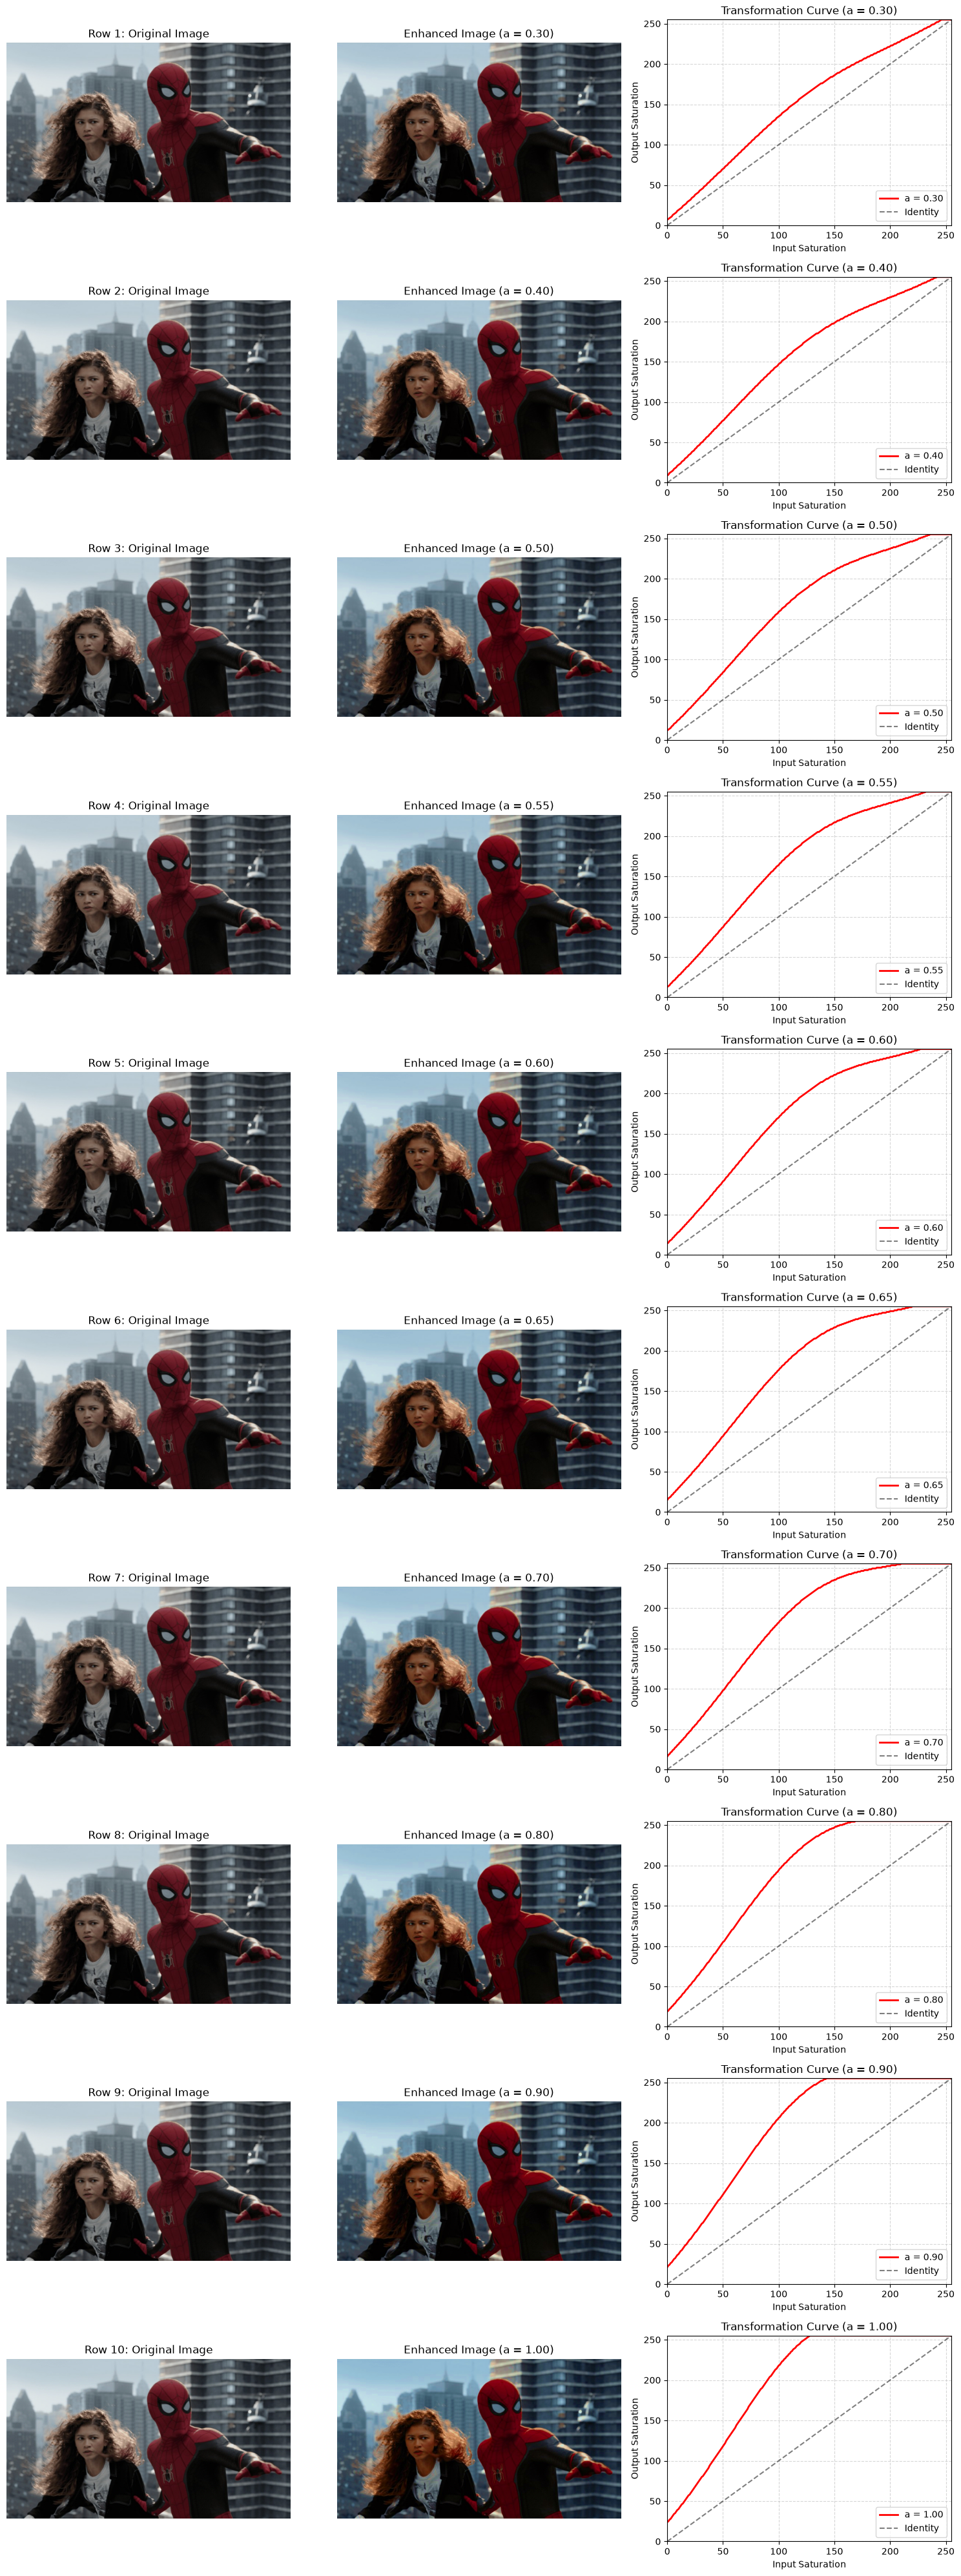

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img_bgr = cv.imread('images/q4.jpeg')
img_rgb_orig = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
h_plane, s_plane, v_plane = cv.split(img_hsv)

def get_vibrance(a: float, sigma: float = 70.0) -> np.ndarray:
    x = np.arange(256, dtype=np.float32)
    gaussian_boost = a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * (sigma ** 2)))
    return np.clip(x + gaussian_boost, 0, 255).astype(np.uint8)


a_values = [0.3, 0.4, 0.5,0.55, 0.6,0.65,0.7, 0.8, 0.9, 1.0]
sigma_val = 70.0
x_axis = np.arange(256)


fig, axes = plt.subplots(len(a_values), 3, figsize=(15, 4 * len(a_values)))

for i, a in enumerate(a_values):
    lut = get_vibrance(a, sigma_val)
    s_enhanced = cv.LUT(s_plane, lut)
    hsv_enhanced = cv.merge([h_plane, s_enhanced, v_plane])
    img_rgb_enhanced = cv.cvtColor(hsv_enhanced, cv.COLOR_HSV2RGB)
    
    axes[i, 0].imshow(img_rgb_orig)
    axes[i, 0].set_title(f'Row {i+1}: Original Image')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(img_rgb_enhanced)
    axes[i, 1].set_title(f'Enhanced Image (a = {a:.2f})')
    axes[i, 1].axis('off')
    
    axes[i, 2].plot(x_axis, lut, 'r-', linewidth=2, label=f'a = {a:.2f}')
    axes[i, 2].plot([0, 255], [0, 255], 'k--', alpha=0.5, label='Identity')
    axes[i, 2].set_title(f'Transformation Curve (a = {a:.2f})')
    axes[i, 2].set_xlabel('Input Saturation')
    axes[i, 2].set_ylabel('Output Saturation')
    axes[i, 2].set_xlim([0, 255])
    axes[i, 2].set_ylim([0, 255])
    axes[i, 2].grid(True, linestyle='--', alpha=0.5)
    axes[i, 2].legend(loc='lower right')

plt.tight_layout()
plt.show()

## Q 05

C:\Users\User\AppData\Local\Temp\ipykernel_13304\1435786972.py:28: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1, 0].hist(img.ravel(), 256, [0, 256], color='gray', alpha=0.8)
C:\Users\User\AppData\Local\Temp\ipykernel_13304\1435786972.py:35: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1, 1].hist(img_equalized.ravel(), 256, [0, 256], color='navy', alpha=0.8)


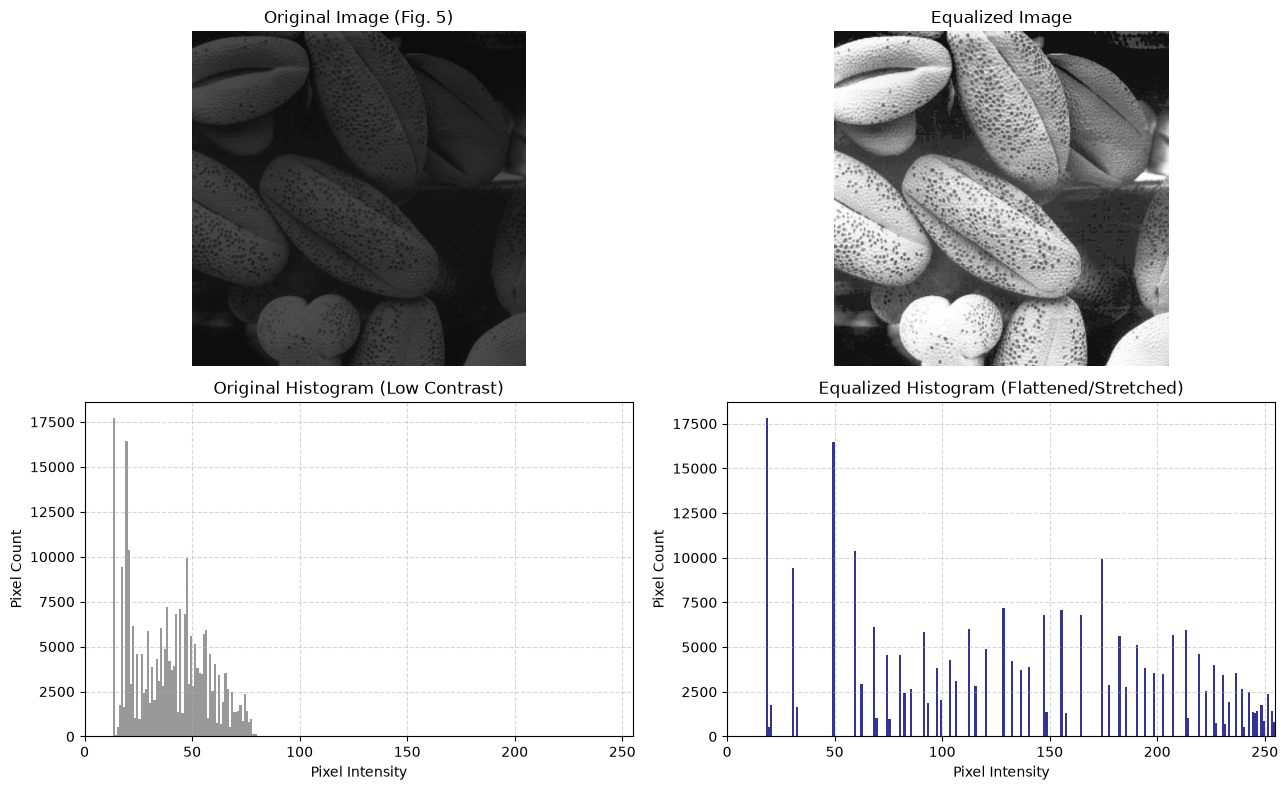

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def histogram_equalization(im: np.ndarray) -> np.ndarray:

    hist, _ = np.histogram(im.flatten(), bins=256, range=[0, 256])
    cdf = hist.cumsum()
    total_pixels = im.size
    cdf_normalized = (cdf / total_pixels) * 255.0
    lut = np.round(cdf_normalized).astype(np.uint8)
    equalized_im = lut[im]
    return equalized_im

img = cv.imread('images/q5.tif', cv.IMREAD_GRAYSCALE)
img_equalized = histogram_equalization(img)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original Image (Fig. 5)')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_equalized, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Equalized Image')
axes[0, 1].axis('off')

axes[1, 0].hist(img.ravel(), 256, [0, 256], color='gray', alpha=0.8)
axes[1, 0].set_title('Original Histogram (Low Contrast)')
axes[1, 0].set_xlabel('Pixel Intensity')
axes[1, 0].set_ylabel('Pixel Count')
axes[1, 0].set_xlim([0, 255])
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

axes[1, 1].hist(img_equalized.ravel(), 256, [0, 256], color='navy', alpha=0.8)
axes[1, 1].set_title('Equalized Histogram (Flattened/Stretched)')
axes[1, 1].set_xlabel('Pixel Intensity')
axes[1, 1].set_ylabel('Pixel Count')
axes[1, 1].set_xlim([0, 255])
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Q 06

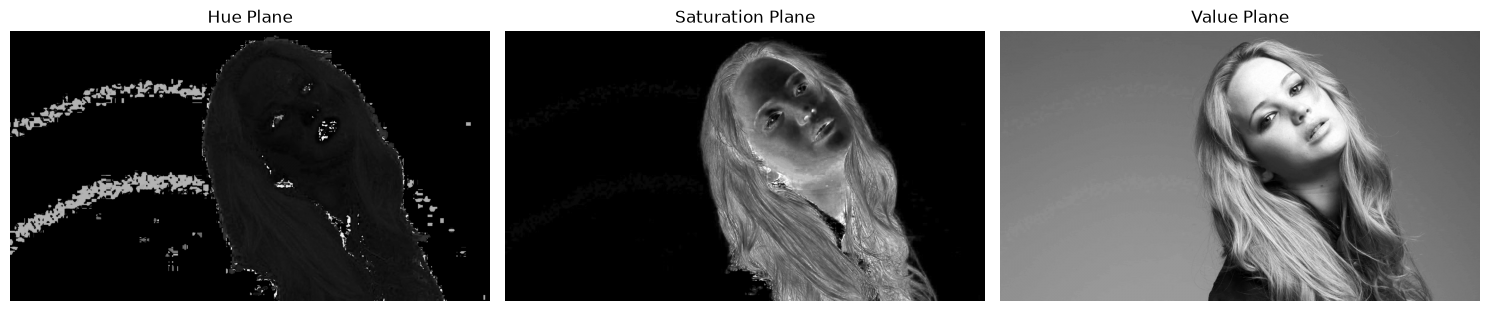

In [24]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('images/q6.jpeg')
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
h, s, v = cv.split(hsv)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(h, cmap='gray')
axes[0].set_title('Hue Plane')
axes[0].axis('off')

axes[1].imshow(s, cmap='gray')
axes[1].set_title('Saturation Plane')
axes[1].axis('off')

axes[2].imshow(v, cmap='gray')
axes[2].set_title('Value Plane')
axes[2].axis('off')

plt.tight_layout()
plt.show()


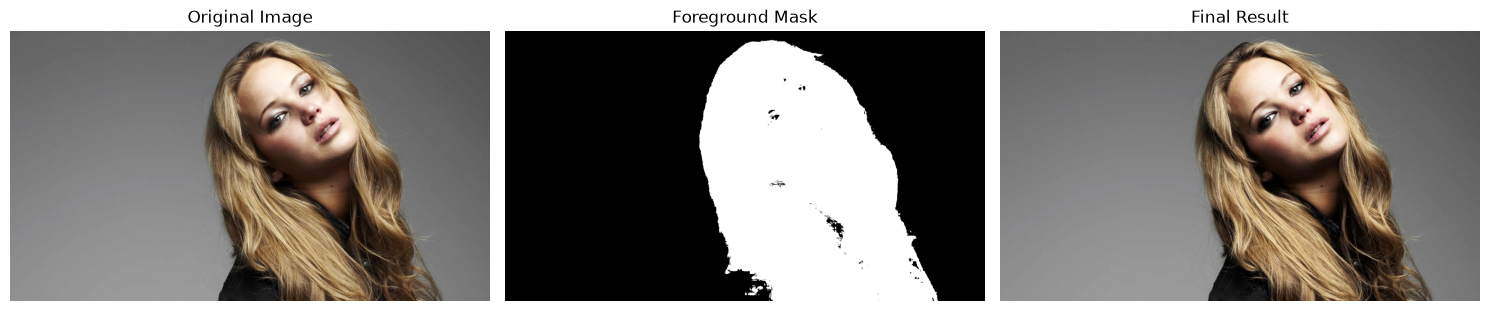

In [52]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

_, mask = cv.threshold(s, 15, 255, cv.THRESH_BINARY)
mask_inv = cv.bitwise_not(mask)

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
extracted_fg_bgr = cv.bitwise_and(img, img, mask=mask)
extracted_fg_rgb = cv.cvtColor(extracted_fg_bgr, cv.COLOR_BGR2RGB)

fg_v_pixels = v[mask > 0]
hist, _ = np.histogram(fg_v_pixels, bins=256, range=[0, 256])

cum_hist = np.cumsum(hist)

L = 256
MN = np.sum(mask > 0)
lut = np.round(((L - 1) / MN) * cum_hist).astype(np.uint8)

v_eq = lut[v]
v_eq_fg = cv.bitwise_and(v_eq, v_eq, mask=mask)

bg_bgr = cv.bitwise_and(img, img, mask=mask_inv)
bg_rgb = cv.cvtColor(bg_bgr, cv.COLOR_BGR2RGB)

hsv_eq = cv.merge([h, s, v_eq])
eq_fg_bgr = cv.bitwise_and(cv.cvtColor(hsv_eq, cv.COLOR_HSV2BGR), cv.cvtColor(hsv_eq, cv.COLOR_HSV2BGR), mask=mask)
eq_fg_rgb = cv.cvtColor(eq_fg_bgr, cv.COLOR_BGR2RGB)

final_bgr = cv.add(eq_fg_bgr, bg_bgr)
final_rgb = cv.cvtColor(final_bgr, cv.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original Image
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

# Foreground Mask
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Foreground Mask')
axes[1].axis('off')

# Final Result
axes[2].imshow(final_rgb)
axes[2].set_title('Final Result')
axes[2].axis('off')

plt.tight_layout()
plt.show()